# **Tutorial Decision Tree Regression - Scikit Learn**

# **Preparação dos Dados**

In [1]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read data
df = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/Admission%20Chance.csv')
df.head()

,Serial No,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [3]:
# define target and features
y = df['Chance of Admit ']
X = df.drop(['Serial No','Chance of Admit '],axis=1)

# **Modelagem**

In [4]:
# Treino e teste
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=2529)

In [5]:
# Instanciando Modelo
from sklearn.tree import DecisionTreeRegressor,plot_tree
dtr=DecisionTreeRegressor(max_depth=3, random_state=2529)

In [6]:
# Trainando Modelo
dtr.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2529
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [7]:
# Avaliação do Modelo no Treino
dtr.score(X_train,y_train)

0.7738322816632399

In [8]:
# Cross validate no Treino
from sklearn.model_selection import cross_validate
cross_validate(dtr, X_train, y_train, cv=5)

{'fit_time': array([0.00201082, 0.00150251, 0.00200033, 0.00099993, 0.00100064]),
 'score_time': array([0.00150371, 0.0010004 , 0.        , 0.0010004 , 0.00100017]),
 'test_score': array([0.62738225, 0.74911799, 0.55230282, 0.8131547 , 0.7219827 ])}

In [9]:
# Avaliação do Modelo no Teste
dtr.score(X_test,y_test)

0.7533283237506997

# **Validação do Modelo**

In [10]:
# Hiperparâmetros do Modelo
dtr.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 2529,
 'splitter': 'best'}

In [11]:
# Seleção de Hiperparâmetros
params = {'model__max_depth' : [2,3,4,5,6,7,8, 9, 10],
        'model__criterion' : ['squared_error', 'absolute_error'],
        'model__random_state' : [2529]}

In [13]:
# import pipeline
from sklearn.pipeline import Pipeline

In [15]:
# define Pipeline
pipe = Pipeline([('model', dtr)])

In [16]:
# grid search cv
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(pipe,params,cv=5)

In [17]:
grid

,estimator,Pipeline(step...state=2529))])
,param_grid,"{'model__criterion': ['squared_error', 'absolute_error'], 'model__max_depth': [2, 3, ...], 'model__random_state': [2529]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [18]:
# Treinando com Grid Search
grid.fit(X_train,y_train)

,estimator,Pipeline(step...state=2529))])
,param_grid,"{'model__criterion': ['squared_error', 'absolute_error'], 'model__max_depth': [2, 3, ...], 'model__random_state': [2529]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [19]:
# Encontrar os Melhores Parâmetros
grid.best_params_

{'model__criterion': 'squared_error',
 'model__max_depth': 3,
 'model__random_state': 2529}

In [20]:
# Selecionando o Melhor Modelo
best = grid.best_estimator_

In [21]:
# Fit Melhor Modelo
best.fit(X_train,y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None


In [22]:
# Predição Melhor Modelo
y_pred=best.predict(X_test)

In [23]:
# model error
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

# mean absolute error
mae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error (MAE):', mae)

# mean absolute percentage error
mape = mean_absolute_percentage_error(y_test, y_pred)
print('Mean Absolute Percentage Error (MAPE):', mape)

# r square
r2 = r2_score(y_test, y_pred)
print('R² (Coeficiente de Determinação):', r2)

Mean Absolute Error (MAE): 0.057160452637289014
Mean Absolute Percentage Error (MAPE): 0.09720961265635472
R² (Coeficiente de Determinação): 0.7533283237506997


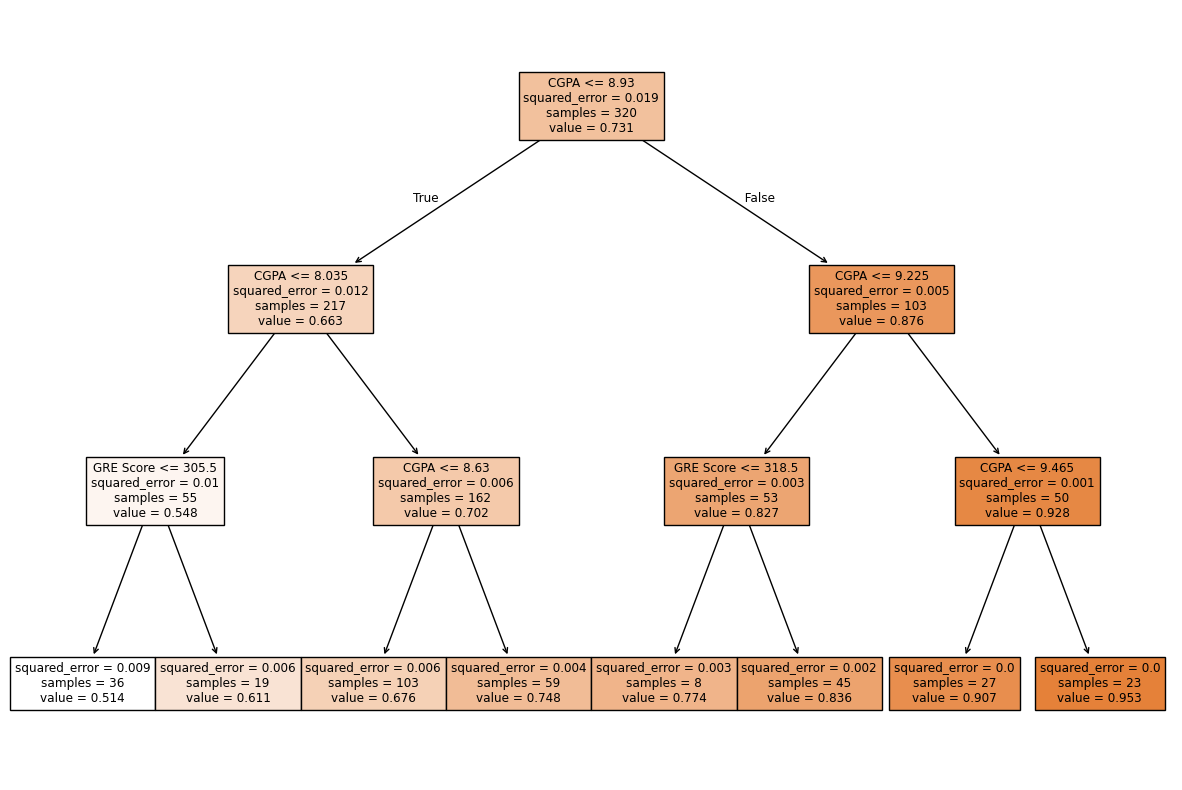

In [24]:
# plot tree
fig,ax = plt.subplots(figsize=(15,10))
final=DecisionTreeRegressor(max_depth=3, random_state=2529)
final.fit(X_train,y_train)
plot_tree(final,feature_names=X.columns,filled=True);

# **Salvando Modelo**

In [26]:
# save model
import pickle

In [27]:
# create an iterator object with write permission - model.pickle
with open('dtr_pkl', 'wb') as files:
    pickle.dump(best, files)

In [28]:
# load saved model
with open('dtr_pkl' , 'rb') as f:
    dtr2 = pickle.load(f)

In [29]:
# predict with saved model
dtr2.predict(X_test)

array([0.67572816, 0.67572816, 0.67572816, 0.67572816, 0.51444444,
       0.90703704, 0.9526087 , 0.74779661, 0.836     , 0.67572816,
       0.61052632, 0.74779661, 0.51444444, 0.77375   , 0.836     ,
       0.67572816, 0.67572816, 0.67572816, 0.74779661, 0.836     ,
       0.61052632, 0.836     , 0.836     , 0.9526087 , 0.74779661,
       0.61052632, 0.67572816, 0.51444444, 0.51444444, 0.61052632,
       0.51444444, 0.74779661, 0.74779661, 0.74779661, 0.61052632,
       0.51444444, 0.51444444, 0.836     , 0.90703704, 0.836     ,
       0.74779661, 0.67572816, 0.67572816, 0.90703704, 0.74779661,
       0.74779661, 0.9526087 , 0.90703704, 0.61052632, 0.51444444,
       0.67572816, 0.67572816, 0.836     , 0.51444444, 0.67572816,
       0.74779661, 0.67572816, 0.67572816, 0.836     , 0.67572816,
       0.67572816, 0.9526087 , 0.67572816, 0.67572816, 0.74779661,
       0.67572816, 0.61052632, 0.9526087 , 0.61052632, 0.90703704,
       0.61052632, 0.9526087 , 0.51444444, 0.67572816, 0.51444